# <font color='teal'> Regularisation in Neural Networks </font>

    Notebook version: 0.1. (Nov 14, 2024)

    Authors: Carlos Sevilla Salcedo (casevill@ing.uc3m.es)

    Changes: v.0.1. (Nov 14, 2024) - First version
    
    Pending changes:
        Examples on transfer learning
        Explore different datasets
        Analyse combinations of regularisation techniques

In [30]:
# Critical plotting imports
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import os

# Set seed
torch.manual_seed(1337)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(1337)
    

%matplotlib inline

size = 14
params = {'legend.fontsize': 'Large',
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.75,
          'ytick.labelsize': size*0.75}
plt.rcParams.update(params)

# <font color='teal'> 1. Introduction </font>

This notebook will be dedicated to exploring the regularisation on neural networks.

## <font color='teal'> Why Regularisation in Neural Networks is Crucial </font>

Neural networks are incredibly powerful tools for modeling complex data relationships. Their ability to approximate non-linear functions has made them a cornerstone of modern machine learning applications, from image recognition to natural language processing.

However, this power comes with a risk: **overfitting**. Neural networks are models that inherently tend to be overparametrised. Wht this means is that by including more layers and make the model deeper the model has enough expressiveness to almost perfectly fit the patterns in the training data, leading to poor generalisation to the test set.  This is mostly observed when a neural network is trained on limited or noisy data. Overfitting results in poor performance on test data, undermining the model's ability to make accurate predictions in real-world scenarios.

Keeping this in mind, how can we ensure that neural networks learn meaningful patterns while avoiding overfitting? The answer lies in **regularisation**—a set of techniques designed to constrain the learning process, making models more robust and generalizable.

In this notebook, we will explore various regularization methods, both theoretical and practical. By the end, you’ll understand how to implement these techniques in PyTorch and evaluate their impact on neural network performance.

## <font color='teal'> Regularisation techniques </font>
There are different approaches that help mitigating the overfitting to the training set. We could group them into:
* __Parametric__: adding prior knowledge to model
  * Initializing weights with specific distributions.
* __Constraining__: restricting the model to simplify it by giving it less degrees of freedom.
  * L1 and L2 (weight decay) regularization, restricting the learnable loss function
  * Early Stopping, restricting the number of iterations
  * Dropout, restricting the number of neurons
* __Indirect__: not regularization but has same effect
  * Batch Normalization
  * Data Augmentation
  * Transfer Learning / Fine Tuning

This notebook provides an introduction to the main concepts necessary to regularise NNs with PyTorch taking materials from:
* <a href="https://gist.github.com/sujitpal/2bffa9d5d93510a201f4064f25c7abad">Regularisation in NNs</a>, by Github user sujitpal
* <a href="https://pytorch.org/tutorials/beginner/pytorch_with_examples.html">Learning PyTorch with Examples</a>, by Justin Johnson
* <a href="https://pytorch.org/tutorials/beginner/nn_tutorial.html">What is *torch.nn* really?</a>, by Jeremy Howard
* <a href="https://www.kaggle.com/kanncaa1/pytorch-tutorial-for-deep-learning-lovers">Pytorch Tutorial for Deep Learning Lovers</a>, by Kaggle user kanncaa1

## <font color='teal'> 2. Datasets </font>

Along this notebook, we will use the `digits` dataset from the previous notebook to run some experiments and explore the different regularisation techniques.

In [72]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

def get_dataset(dataset_name, forze_binary=False):
    """
    Loads the selected dataset, among two options: DogsCats or digits.

    If dataset_name == 'digits', you can take a dataset with two classes only,
    using forze_binary == True
    """

    if dataset_name == 'DogsCats':
        DogsCatsX = np.load('./data/DogsCats/X.npy')
        DogsCatsY = np.load('./data/DogsCats/Y.npy')

        # Flatten images to get 1D inputs
        K = DogsCatsX.shape[0]
        img_size = DogsCatsX.shape[1]
        DogsCatsX_flatten = DogsCatsX.reshape(K,img_size*img_size)
        X = DogsCatsX_flatten
        y = DogsCatsY
    elif dataset_name == 'digits':
        digitsX = np.load('./data/Sign-language-digits-dataset/X.npy')
        digitsY = np.load('./data/Sign-language-digits-dataset/Y.npy')

        # Flatten images (to get 1-dimensional inputs
        K = digitsX.shape[0]
        img_size = digitsX.shape[1]
        digitsX_flatten = digitsX.reshape(K,img_size*img_size)
        if forze_binary:
            # Zero and Ones are one hot encoded in columns 1 and 4
            X0 = digitsX_flatten[np.argmax(digitsY, axis=1)==1,]
            X1 = digitsX_flatten[np.argmax(digitsY, axis=1)==4,]
            X = np.vstack((X0, X1))
            y = np.zeros(X.shape[0])
            y[X0.shape[0]:] = 1
        else:
            X = digitsX_flatten
            y = digitsY
    else:
        print("-- ERROR: Unknown dataset")
        return

    # Joint normalization of all data. For images [-.5, .5] scaling is frequent
    min_max_scaler = MinMaxScaler(feature_range=(-.5, .5))
    X = min_max_scaler.fit_transform(X)

    # Generate train and validation data, shuffle
    X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)
    X_train, X_val, y_train, y_val = train_test_split(X_tr, y_tr, test_size=0.3, random_state=42, shuffle=True)

    return X_train, X_val, X_test, y_train, y_val, y_test

Now, we will define the dataset we will utilise for the following sections. Depending on how fast you want to run the experiments or the device in which you are doing it you might want to tweak the number of samples. However, to fully observe the overfitting we are exploring is recommended to use the whole dataset.

train :  1010
valid :  433
test  :  619
train batch shape: torch.Size([64, 4096])


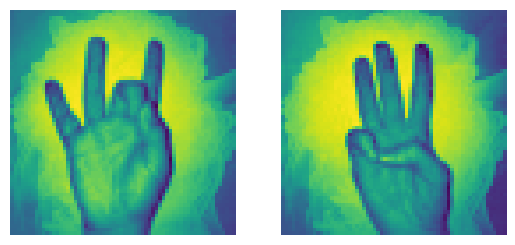

Labels corresponding to figures: [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]


In [73]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
dataset = 'digits' # 'digits' or 'DogsCats'
N = 5000 # Number of samples to use for training, -1 for all, 5000 for testing

X_train, X_val, X_test, y_train, y_val, y_test = get_dataset(dataset)

min_max_scaler = MinMaxScaler(feature_range=(-.5, .5))
X_train = min_max_scaler.fit_transform(X_train)
X_val = min_max_scaler.transform(X_val)
X_test = min_max_scaler.transform(X_test)

# Convert to Torch tensors
X_train_torch = torch.from_numpy(X_train[:N]) if N != -1 else torch.from_numpy(X_train).to(device)
X_val_torch = torch.from_numpy(X_val).to(device)
X_test_torch = torch.from_numpy(X_test).to(device)
y_train_torch = torch.from_numpy(y_train[:N]) if N != -1 else torch.from_numpy(y_train).to(device)
y_val_torch = torch.from_numpy(y_val).to(device)
y_test_torch = torch.from_numpy(y_test).to(device)

batch_size = 64

ds_train = TensorDataset(X_train_torch, y_train_torch)
ds_valid = TensorDataset(X_val_torch, y_val_torch)
ds_test = TensorDataset(X_test_torch, y_test_torch)
train_loader = DataLoader(ds_train, batch_size=batch_size)
valid_loader = DataLoader(ds_valid, batch_size=batch_size)
test_loader = DataLoader(ds_test, batch_size=batch_size)
# Now we've training, validation and test set
print('train : ', len(ds_train))
print('valid : ', len(ds_valid))
print('test  : ', len(ds_test))
test_batch = next(train_loader.__iter__())
print('train batch shape:', test_batch[0].shape)

# Show sample images
selected = [260, 340]
img_size = int(np.sqrt(X_train.shape[1]))
plt.subplot(1, 2, 1), plt.imshow(X_train[selected[0]].reshape(img_size, img_size)), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(X_train[selected[1]].reshape(img_size, img_size)), plt.axis('off')
plt.show()
print('Labels corresponding to figures:', y_train[selected,])

## <font color='teal'> 3. Base network </font>

This section presents the basic structure of the neural network we will start from. Thi is composed solely of linear layers followed by their corresponding activation functions and one last layer for classification.

In [74]:
class FeedforwardNeuralNetModel(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim= (200, 50, 20)):
        super(FeedforwardNeuralNetModel, self).__init__()

        sizes = [input_dim] + list(map(int, hidden_dim)) + [output_dim]
        layers = []
        for i in range(len(sizes) - 2):
            layers.append(nn.Linear(sizes[i], sizes[i + 1]))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(sizes[-2], sizes[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, x):        
        out = self.net(x)    
        return out

We can explore different configurations of the neural network just by increasing the number of hidden dimensions.

In [75]:
input_dim = train_loader.dataset.tensors[0].shape[1]
hidden_dim = (200, 50, 20)
output_dim = train_loader.dataset.tensors[1].shape[1] if dataset == 'digits' else 1

# Instantiate model class and assign to object
model = FeedforwardNeuralNetModel(input_dim, output_dim, hidden_dim)

# Push model to CUDA device if available
model.to(device)

# Loss function (binary if DogsCats, otherwise multi-class)
loss_func = nn.BCEWithLogitsLoss() if dataset == 'DogsCats' else nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=1e-1)

Notice how we have used the `BCEWithLogitsLoss` loss function. This is because we are using a sigmoid activation function in the output layer. This function combines a sigmoid activation function with the binary cross-entropy loss. This is useful when we are dealing with binary classification problems.

Let's take a look now at the number of parameters in our network.

In [76]:
# Number of groups of parameters
print('Number of groups of parameters {}'.format(len(list(model.parameters()))))
print('-'*50)
# Print parameters
for i in range(len(list(model.parameters()))):
    print(list(model.parameters())[i].size())
print('-'*50)

Number of groups of parameters 8
--------------------------------------------------
torch.Size([200, 4096])
torch.Size([200])
torch.Size([50, 200])
torch.Size([50])
torch.Size([20, 50])
torch.Size([20])
torch.Size([10, 20])
torch.Size([10])
--------------------------------------------------


You can observe how the number of parameters in the model is increasing as we add more layers. The number of parameters in the model is given by the number of weights and biases in the model. The number of weights in a layer is given by the number of neurons in the current layer multiplied by the number of neurons in the previous layer. The number of biases in a layer is given by the number of neurons in the current layer. The number of parameters in a layer is given by the sum of the number of weights and biases in the layer.

Let's train our network to see how it performs in our classification task.

In [77]:
def accuracy(q, y):
    return (y.argmax(axis=-1) == q.argmax(axis=-1)).float().mean()

In [78]:
num_epochs = 100
best_accuracy = 0
loss_train = np.zeros(num_epochs)
loss_val = np.zeros(num_epochs)
acc_train = np.zeros(num_epochs)
acc_val = np.zeros(num_epochs)

# Check if the best model exists
pretrained = False
hidden_dim_str = '_'.join(map(str, hidden_dim))
model_path = f'models/best_model_{dataset}_N{int(X_train_torch.shape[0])}_hidden{hidden_dim_str}.pth'
if os.path.exists(model_path) and pretrained:
    print("Loading best model and training history...")
    checkpoint = torch.load(model_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    loss_train = checkpoint['loss_train']
    loss_val = checkpoint['loss_val']
    acc_train = checkpoint['acc_train']
    acc_val = checkpoint['acc_val']
    best_accuracy = checkpoint['best_accuracy']
else:
    print("Best model not found. Running optimization...")

    for epoch in range(num_epochs):

        for xb, yb in train_loader:
            # Ensure the input tensors are of type float32
            xb = xb.float().to(device)
            yb = yb.reshape(-1, 1).float() if dataset == 'DogsCats' else yb.argmax(axis=-1).to(device)

            #Compute network output and cross-entropy loss for current minibatch
            pred = model(xb)
            loss = loss_func(pred, yb)

            #Compute gradients and optimize parameters
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
                
        #At the end of each epoch, evaluate overall network performance
        with torch.no_grad():
            #Computing network performance after iteration
            pred = model(X_train_torch.float().to(device))
            loss_train[epoch] = loss_func(pred, y_train_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred, y_train_torch.argmax(axis=-1).to(device)).item()
            acc_train[epoch] = accuracy(pred, y_train_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred, y_train_torch.to(device)).item()
            pred_val = model(X_val_torch.float().to(device))
            loss_val[epoch] = loss_func(pred_val, y_val_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred_val, y_val_torch.argmax(axis=-1).to(device)).item()
            acc_val[epoch] = accuracy(pred_val, y_val_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred_val, y_val_torch.to(device)).item()
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss_train[epoch]:.4f}, Accuracy: {acc_train[epoch]:.4f}, Val Loss: {loss_val[epoch]:.4f}, Val Accuracy: {acc_val[epoch]:.4f}')
        
        # Save model when accuracy beats best accuracy
        if acc_val[epoch] > best_accuracy:
            best_accuracy = acc_val[epoch]
            # Save the model state and training history
            torch.save({
                'model_state_dict': model.state_dict(),
                'loss_train': loss_train,
                'loss_val': loss_val,
                'acc_train': acc_train,
                'acc_val': acc_val,
                'best_accuracy': best_accuracy
            }, model_path)

# Get test performance
with torch.no_grad():
    pred_test = model(X_test_torch.float().to(device))
    loss_test = loss_func(pred_test, y_test_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred_test, y_test_torch.argmax(axis=-1).to(device)).item()
    acc_test = accuracy(pred_test, y_test_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred_test, y_test_torch.to(device)).item()
print(f'Test Loss: {loss_test:.4f}, Test Accuracy: {acc_test:.4f}')

Best model not found. Running optimization...
Epoch [1/100], Loss: 2.2957, Accuracy: 0.0921, Val Loss: 2.2978, Val Accuracy: 0.1224
Epoch [2/100], Loss: 2.2777, Accuracy: 0.2188, Val Loss: 2.2890, Val Accuracy: 0.1778
Epoch [3/100], Loss: 2.2463, Accuracy: 0.2337, Val Loss: 2.2687, Val Accuracy: 0.1824
Epoch [4/100], Loss: 2.1869, Accuracy: 0.2752, Val Loss: 2.2277, Val Accuracy: 0.1940
Epoch [5/100], Loss: 2.0659, Accuracy: 0.2842, Val Loss: 2.1363, Val Accuracy: 0.2333
Epoch [6/100], Loss: 1.9002, Accuracy: 0.2911, Val Loss: 2.0296, Val Accuracy: 0.2194
Epoch [7/100], Loss: 1.7661, Accuracy: 0.3347, Val Loss: 1.9266, Val Accuracy: 0.2748
Epoch [8/100], Loss: 1.7602, Accuracy: 0.3465, Val Loss: 1.9160, Val Accuracy: 0.2725
Epoch [9/100], Loss: 1.7060, Accuracy: 0.3861, Val Loss: 2.0312, Val Accuracy: 0.2956
Epoch [10/100], Loss: 1.4835, Accuracy: 0.4713, Val Loss: 1.8080, Val Accuracy: 0.3926
Epoch [11/100], Loss: 1.4698, Accuracy: 0.4782, Val Loss: 1.7184, Val Accuracy: 0.3972
Epoch 

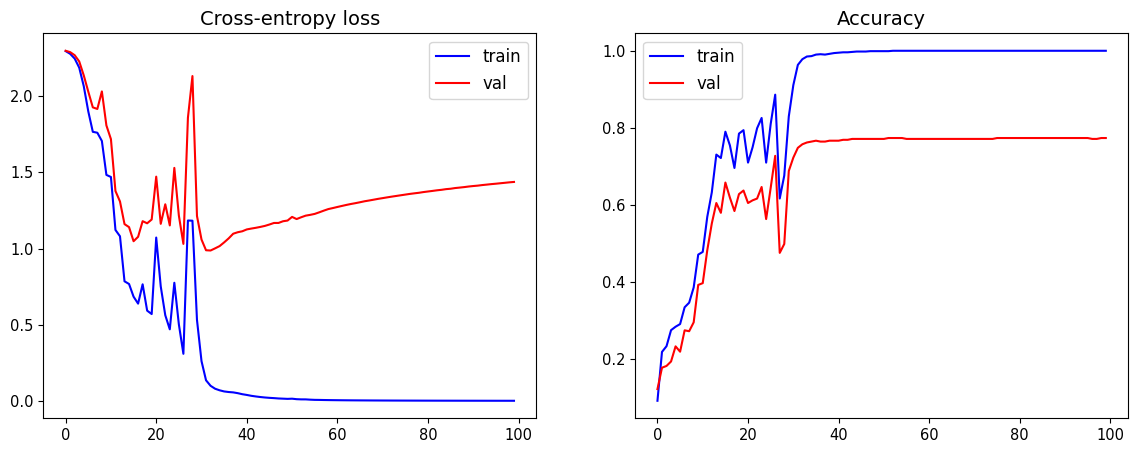

In [79]:
plt.figure(figsize=(14,5))
plt.subplot(1, 2, 1), plt.plot(loss_train, 'b'), plt.plot(loss_val, 'r'), plt.legend(['train', 'val']), plt.title('Cross-entropy loss')
plt.subplot(1, 2, 2), plt.plot(acc_train, 'b'), plt.plot(acc_val, 'r'), plt.legend(['train', 'val']), plt.title('Accuracy')
plt.show()

## <font color='teal'> 4. Parametric regularisation </font>

These techniques introduce prior knowledge into the model through constraints on the parameters.

**Weight Initialization:**  
By initializing weights using specific distributions, we can guide the model toward better convergence and avoid poor local minima. Common initialization methods include:
- **Xavier Initialization:** Scales weights based on the number of neurons in the layer, promoting stable gradients.
- **He Initialization:** Tailored for activation functions like ReLU, it initializes weights to prevent vanishing/exploding gradients.

Let's modify our network to test this initialisation technique.

In [80]:
class FeedforwardNeuralNetModel(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim= (200, 50, 20), initialize_weights=False):
        super(FeedforwardNeuralNetModel, self).__init__()

        sizes = [input_dim] + list(map(int, hidden_dim)) + [output_dim]
        layers = []
        for i in range(len(sizes) - 2):
            layers.append(nn.Linear(sizes[i], sizes[i + 1]))
            if initialize_weights:
                torch.nn.init.xavier_uniform_(layers[-1].weight)
            layers.append(nn.ReLU())
        layers.append(nn.Linear(sizes[-2], sizes[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, x):        
        out = self.net(x)    
        return out

In [81]:
input_dim = train_loader.dataset.tensors[0].shape[1]
hidden_dim = (200, 50, 20)
output_dim = train_loader.dataset.tensors[1].shape[1] if dataset == 'digits' else 1

# Instantiate model class and assign to object
model = FeedforwardNeuralNetModel(input_dim, output_dim, hidden_dim, initialize_weights=True)

# Push model to CUDA device if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

# Loss function
loss_func = nn.BCEWithLogitsLoss() if dataset == 'DogsCats' else nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [82]:
num_epochs = 100
best_accuracy = 0
loss_train = np.zeros(num_epochs)
loss_val = np.zeros(num_epochs)
acc_train = np.zeros(num_epochs)
acc_val = np.zeros(num_epochs)

# Check if the best model exists
reg_technique = 'He'
pretrained = False
hidden_dim_str = '_'.join(map(str, hidden_dim))
model_path = f'models/best_model_{dataset}_{reg_technique}_N{int(X_train_torch.shape[0])}_hidden{hidden_dim_str}.pth'
if os.path.exists(model_path) and pretrained:
    print("Loading best model and training history...")
    checkpoint = torch.load(model_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    loss_train = checkpoint['loss_train']
    loss_val = checkpoint['loss_val']
    acc_train = checkpoint['acc_train']
    acc_val = checkpoint['acc_val']
    best_accuracy = checkpoint['best_accuracy']
else:
    print("Best model not found. Running optimization...")

    for epoch in range(num_epochs):

        for xb, yb in train_loader:
            # Ensure the input tensors are of type float32
            xb = xb.float().to(device)
            yb = yb.reshape(-1, 1).float().to(device) if dataset == 'DogsCats' else yb.argmax(axis=-1).to(device)

            #Compute network output and cross-entropy loss for current minibatch
            pred = model(xb)
            loss = loss_func(pred, yb)

            #Compute gradients and optimize parameters
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
                
        #At the end of each epoch, evaluate overall network performance
        with torch.no_grad():
            #Computing network performance after iteration
            pred = model(X_train_torch.float().to(device))
            loss_train[epoch] = loss_func(pred, y_train_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred, y_train_torch.argmax(axis=-1).to(device)).item()
            acc_train[epoch] = accuracy(pred, y_train_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred, y_train_torch.to(device)).item()
            pred_val = model(X_val_torch.float().to(device))
            loss_val[epoch] = loss_func(pred_val, y_val_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred_val, y_val_torch.argmax(axis=-1).to(device)).item()
            acc_val[epoch] = accuracy(pred_val, y_val_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred_val, y_val_torch.to(device)).item()
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss_train[epoch]:.4f}, Accuracy: {acc_train[epoch]:.4f}, Val Loss: {loss_val[epoch]:.4f}, Val Accuracy: {acc_val[epoch]:.4f}')
        
        # Save model when accuracy beats best accuracy
        if acc_val[epoch] > best_accuracy:
            best_accuracy = acc_val[epoch]
            # Save the model state and training history
            torch.save({
                'model_state_dict': model.state_dict(),
                'loss_train': loss_train,
                'loss_val': loss_val,
                'acc_train': acc_train,
                'acc_val': acc_val,
                'best_accuracy': best_accuracy
            }, model_path)
            
# Get test performance
with torch.no_grad():
    pred_test = model(X_test_torch.float().to(device))
    loss_test = loss_func(pred_test, y_test_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred_test, y_test_torch.argmax(axis=-1).to(device)).item()
    acc_test = accuracy(pred_test, y_test_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred_test, y_test_torch.to(device)).item()
print(f'Test Loss: {loss_test:.4f}, Test Accuracy: {acc_test:.4f}')

Best model not found. Running optimization...
Epoch [1/100], Loss: 1.9562, Accuracy: 0.2941, Val Loss: 2.0749, Val Accuracy: 0.2309
Epoch [2/100], Loss: 1.4940, Accuracy: 0.5010, Val Loss: 1.6650, Val Accuracy: 0.4065
Epoch [3/100], Loss: 1.0860, Accuracy: 0.7010, Val Loss: 1.3558, Val Accuracy: 0.5658
Epoch [4/100], Loss: 0.8024, Accuracy: 0.7812, Val Loss: 1.1525, Val Accuracy: 0.6443
Epoch [5/100], Loss: 0.6109, Accuracy: 0.8297, Val Loss: 1.0290, Val Accuracy: 0.6790
Epoch [6/100], Loss: 0.5068, Accuracy: 0.8634, Val Loss: 0.9924, Val Accuracy: 0.6859
Epoch [7/100], Loss: 0.4134, Accuracy: 0.8901, Val Loss: 0.9640, Val Accuracy: 0.7136
Epoch [8/100], Loss: 0.3227, Accuracy: 0.9218, Val Loss: 0.9435, Val Accuracy: 0.7113
Epoch [9/100], Loss: 0.3108, Accuracy: 0.9178, Val Loss: 1.0291, Val Accuracy: 0.6975
Epoch [10/100], Loss: 0.2943, Accuracy: 0.9188, Val Loss: 1.0992, Val Accuracy: 0.6859
Epoch [11/100], Loss: 0.2453, Accuracy: 0.9376, Val Loss: 1.0007, Val Accuracy: 0.7021
Epoch 

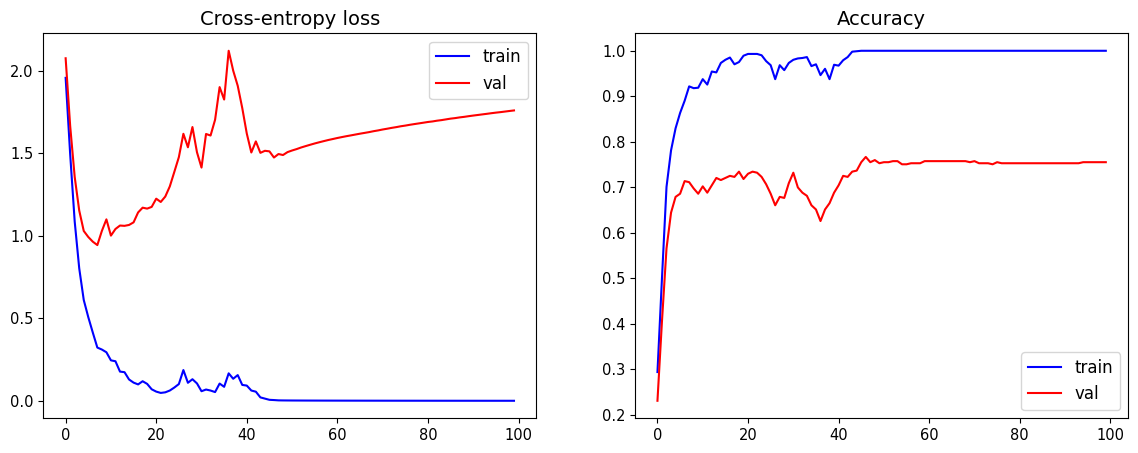

In [83]:
plt.figure(figsize=(14,5))
plt.subplot(1, 2, 1), plt.plot(loss_train, 'b'), plt.plot(loss_val, 'r'), plt.legend(['train', 'val']), plt.title('Cross-entropy loss')
plt.subplot(1, 2, 2), plt.plot(acc_train, 'b'), plt.plot(acc_val, 'r'), plt.legend(['train', 'val']), plt.title('Accuracy')
plt.show()

In [84]:
input_dim = train_loader.dataset.tensors[0].shape[1]
hidden_dim = (200, 50, 20)
output_dim = train_loader.dataset.tensors[1].shape[1] if dataset == 'digits' else 1

# Instantiate model class and assign to object
model = FeedforwardNeuralNetModel(input_dim, output_dim, hidden_dim, initialize_weights=True)

# Push model to CUDA device if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

# Loss function
loss_func = nn.BCEWithLogitsLoss() if dataset == 'DogsCats' else nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [85]:
num_epochs = 100
best_accuracy = 0
loss_train = np.zeros(num_epochs)
loss_val = np.zeros(num_epochs)
acc_train = np.zeros(num_epochs)
acc_val = np.zeros(num_epochs)

# Check if the best model exists
reg_technique = 'xavier'
pretrained = False
hidden_dim_str = '_'.join(map(str, hidden_dim))
model_path = f'models/best_model_{dataset}_{reg_technique}_N{int(X_train_torch.shape[0])}_hidden{hidden_dim_str}.pth'
if os.path.exists(model_path) and pretrained:
    print("Loading best model and training history...")
    checkpoint = torch.load(model_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    loss_train = checkpoint['loss_train']
    loss_val = checkpoint['loss_val']
    acc_train = checkpoint['acc_train']
    acc_val = checkpoint['acc_val']
    best_accuracy = checkpoint['best_accuracy']
else:
    print("Best model not found. Running optimization...")

    for epoch in range(num_epochs):

        for xb, yb in train_loader:
            # Ensure the input tensors are of type float32
            xb = xb.float().to(device)
            yb = yb.reshape(-1, 1).float().to(device) if dataset == 'DogsCats' else yb.argmax(axis=-1).to(device)

            #Compute network output and cross-entropy loss for current minibatch
            pred = model(xb)
            loss = loss_func(pred, yb)

            #Compute gradients and optimize parameters
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
                
        #At the end of each epoch, evaluate overall network performance
        with torch.no_grad():
            #Computing network performance after iteration
            pred = model(X_train_torch.float().to(device))
            loss_train[epoch] = loss_func(pred, y_train_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred, y_train_torch.argmax(axis=-1).to(device)).item()
            acc_train[epoch] = accuracy(pred, y_train_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred, y_train_torch.to(device)).item()
            pred_val = model(X_val_torch.float().to(device))
            loss_val[epoch] = loss_func(pred_val, y_val_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred_val, y_val_torch.argmax(axis=-1).to(device)).item()
            acc_val[epoch] = accuracy(pred_val, y_val_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred_val, y_val_torch.to(device)).item()
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss_train[epoch]:.4f}, Accuracy: {acc_train[epoch]:.4f}, Val Loss: {loss_val[epoch]:.4f}, Val Accuracy: {acc_val[epoch]:.4f}')
        
        # Save model when accuracy beats best accuracy
        if acc_val[epoch] > best_accuracy:
            best_accuracy = acc_val[epoch]
            # Save the model state and training history
            torch.save({
                'model_state_dict': model.state_dict(),
                'loss_train': loss_train,
                'loss_val': loss_val,
                'acc_train': acc_train,
                'acc_val': acc_val,
                'best_accuracy': best_accuracy
            }, model_path)
# Get test performance
with torch.no_grad():
    pred_test = model(X_test_torch.float().to(device))
    loss_test = loss_func(pred_test, y_test_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred_test, y_test_torch.argmax(axis=-1).to(device)).item()
    acc_test = accuracy(pred_test, y_test_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred_test, y_test_torch.to(device)).item()
print(f'Test Loss: {loss_test:.4f}, Test Accuracy: {acc_test:.4f}')

Best model not found. Running optimization...
Epoch [1/100], Loss: 2.1074, Accuracy: 0.2673, Val Loss: 2.1454, Val Accuracy: 0.2148
Epoch [2/100], Loss: 1.7811, Accuracy: 0.3941, Val Loss: 1.8896, Val Accuracy: 0.3187
Epoch [3/100], Loss: 1.4450, Accuracy: 0.5554, Val Loss: 1.6636, Val Accuracy: 0.4480
Epoch [4/100], Loss: 1.1528, Accuracy: 0.6257, Val Loss: 1.4329, Val Accuracy: 0.5104
Epoch [5/100], Loss: 0.8939, Accuracy: 0.7406, Val Loss: 1.2285, Val Accuracy: 0.5704
Epoch [6/100], Loss: 0.6932, Accuracy: 0.8069, Val Loss: 1.0865, Val Accuracy: 0.6166
Epoch [7/100], Loss: 0.5937, Accuracy: 0.8347, Val Loss: 1.0779, Val Accuracy: 0.6259
Epoch [8/100], Loss: 0.5088, Accuracy: 0.8515, Val Loss: 1.0553, Val Accuracy: 0.6397
Epoch [9/100], Loss: 0.4096, Accuracy: 0.9020, Val Loss: 0.9916, Val Accuracy: 0.6836
Epoch [10/100], Loss: 0.4367, Accuracy: 0.8723, Val Loss: 1.1140, Val Accuracy: 0.6490
Epoch [11/100], Loss: 0.3219, Accuracy: 0.9188, Val Loss: 1.0457, Val Accuracy: 0.6744
Epoch 

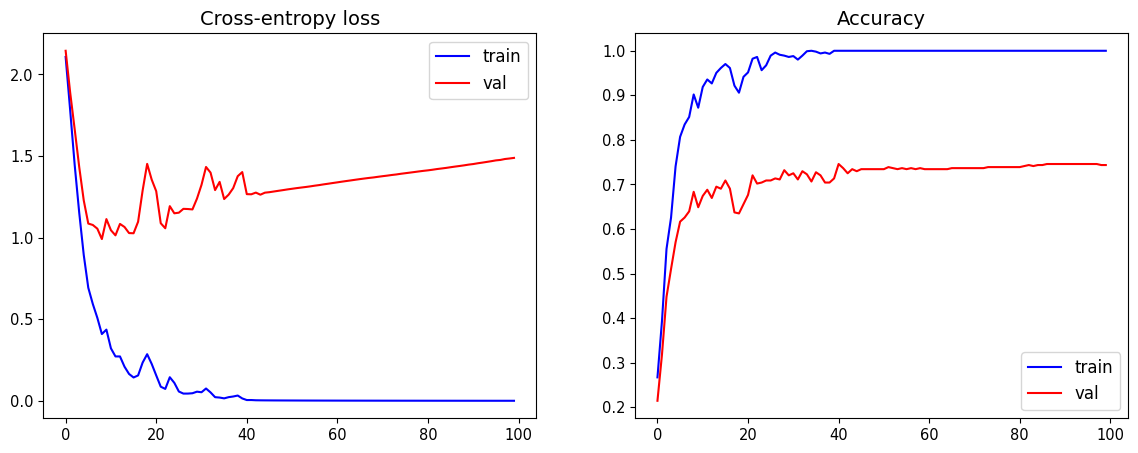

In [86]:
plt.figure(figsize=(14,5))
plt.subplot(1, 2, 1), plt.plot(loss_train, 'b'), plt.plot(loss_val, 'r'), plt.legend(['train', 'val']), plt.title('Cross-entropy loss')
plt.subplot(1, 2, 2), plt.plot(acc_train, 'b'), plt.plot(acc_val, 'r'), plt.legend(['train', 'val']), plt.title('Accuracy')
plt.show()

It seems like using He initialisation slightly improves the performance of the model in validation. However, he improvement is not substantial.

## <font color='teal'> 5. Constraining regularisation </font>
Techniques that directly constrain the function being learned by adding penalties to different parts of the network.

### <font color='teal'> 5.1. Lasso regularisation </font>
Adds a l1 penalty proportional to the sum of the absolute values of the weights. Encourages sparsity (i.e., some weights become zero).
  $$
  L = L_{\text{original}} + \lambda \sum |w_i|
  $$
Let's modify our optimisation to restrict the weights of the network towards 0. This is done by adding a regularizer term to the loss function containing the 1-norm of the parameters of the model.

In [87]:
input_dim = train_loader.dataset.tensors[0].shape[1]
hidden_dim = (200, 50, 20)
output_dim = train_loader.dataset.tensors[1].shape[1] if dataset == 'digits' else 1

# Instantiate model class and assign to object
model = FeedforwardNeuralNetModel(input_dim, output_dim, hidden_dim)

# Push model to CUDA device if available
model.to(device)

# Loss function
loss_func = nn.BCEWithLogitsLoss() if dataset == 'DogsCats' else nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [88]:
num_epochs = 100
best_accuracy = 0
loss_train = np.zeros(num_epochs)
loss_val = np.zeros(num_epochs)
acc_train = np.zeros(num_epochs)
acc_val = np.zeros(num_epochs)

# Check if the best model exists
l1_lambda = 1e-3
reg_technique = 'l1'
pretrained = False
hidden_dim_str = '_'.join(map(str, hidden_dim))
model_path = f'models/best_model_{dataset}_{reg_technique}_{l1_lambda}_N{int(X_train_torch.shape[0])}_hidden{hidden_dim_str}.pth'
if os.path.exists(model_path) and pretrained:
    print("Loading best model and training history...")
    checkpoint = torch.load(model_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    loss_train = checkpoint['loss_train']
    loss_val = checkpoint['loss_val']
    acc_train = checkpoint['acc_train']
    acc_val = checkpoint['acc_val']
    best_accuracy = checkpoint['best_accuracy']
else:
    print("Best model not found. Running optimization...")

    for epoch in range(num_epochs):

        for xb, yb in train_loader:
            # Ensure the input tensors are of type float32
            xb = xb.float().to(device)
            yb = yb.reshape(-1, 1).float().to(device) if dataset == 'DogsCats' else yb.argmax(axis=-1).to(device)

            #Compute network output and cross-entropy loss for current minibatch
            pred = model(xb)
            loss = loss_func(pred, yb)
            # ####################################################################
            # Apply L1 regularization to all layers
            l1_norm = 0

            for name, param in model.named_parameters():
                if 'weight' in name:
                    l1_norm += torch.norm(param, 1)

            loss += l1_lambda * l1_norm
            # ####################################################################

            #Compute gradients and optimize parameters
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
                
        #At the end of each epoch, evaluate overall network performance
        with torch.no_grad():
            #Computing network performance after iteration
            pred = model(X_train_torch.float().to(device))
            loss_train[epoch] = loss_func(pred, y_train_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred, y_train_torch.argmax(axis=-1).to(device)).item()
            acc_train[epoch] = accuracy(pred, y_train_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred, y_train_torch.to(device)).item()
            pred_val = model(X_val_torch.float().to(device))
            loss_val[epoch] = loss_func(pred_val, y_val_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred_val, y_val_torch.argmax(axis=-1).to(device)).item()
            acc_val[epoch] = accuracy(pred_val, y_val_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred_val, y_val_torch.to(device)).item()
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss_train[epoch]:.4f}, Accuracy: {acc_train[epoch]:.4f}, Val Loss: {loss_val[epoch]:.4f}, Val Accuracy: {acc_val[epoch]:.4f}')
        
        # Save model when accuracy beats best accuracy
        if acc_val[epoch] > best_accuracy:
            best_accuracy = acc_val[epoch]
            # Save the model state and training history
            torch.save({
                'model_state_dict': model.state_dict(),
                'loss_train': loss_train,
                'loss_val': loss_val,
                'acc_train': acc_train,
                'acc_val': acc_val,
                'best_accuracy': best_accuracy
            }, model_path)
# Get test performance
with torch.no_grad():
    pred_test = model(X_test_torch.float().to(device))
    loss_test = loss_func(pred_test, y_test_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred_test, y_test_torch.argmax(axis=-1).to(device)).item()
    acc_test = accuracy(pred_test, y_test_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred_test, y_test_torch.to(device)).item()
print(f'Test Loss: {loss_test:.4f}, Test Accuracy: {acc_test:.4f}')

Best model not found. Running optimization...
Epoch [1/100], Loss: 2.3198, Accuracy: 0.0921, Val Loss: 2.2985, Val Accuracy: 0.1178
Epoch [2/100], Loss: 2.3198, Accuracy: 0.0921, Val Loss: 2.2998, Val Accuracy: 0.1178
Epoch [3/100], Loss: 2.3180, Accuracy: 0.0921, Val Loss: 2.2996, Val Accuracy: 0.1178
Epoch [4/100], Loss: 2.3163, Accuracy: 0.0921, Val Loss: 2.2995, Val Accuracy: 0.1178
Epoch [5/100], Loss: 2.3148, Accuracy: 0.0921, Val Loss: 2.2994, Val Accuracy: 0.1178
Epoch [6/100], Loss: 2.3134, Accuracy: 0.0921, Val Loss: 2.2994, Val Accuracy: 0.1178
Epoch [7/100], Loss: 2.3122, Accuracy: 0.0921, Val Loss: 2.2994, Val Accuracy: 0.1178
Epoch [8/100], Loss: 2.3110, Accuracy: 0.1119, Val Loss: 2.2995, Val Accuracy: 0.0947
Epoch [9/100], Loss: 2.3099, Accuracy: 0.1119, Val Loss: 2.2997, Val Accuracy: 0.0947
Epoch [10/100], Loss: 2.3088, Accuracy: 0.1119, Val Loss: 2.2998, Val Accuracy: 0.0947
Epoch [11/100], Loss: 2.3078, Accuracy: 0.1119, Val Loss: 2.3001, Val Accuracy: 0.0947
Epoch 

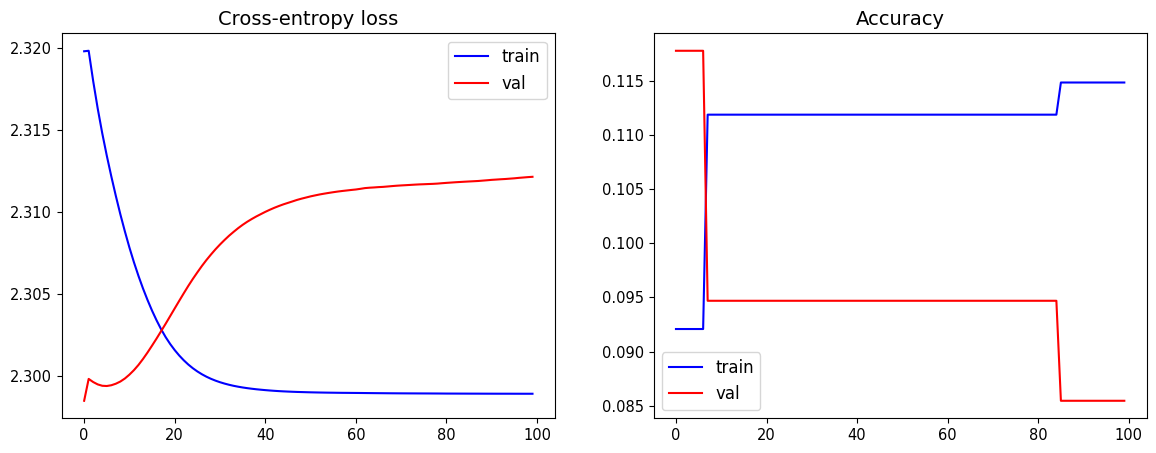

In [89]:
plt.figure(figsize=(14,5))
plt.subplot(1, 2, 1), plt.plot(loss_train, 'b'), plt.plot(loss_val, 'r'), plt.legend(['train', 'val']), plt.title('Cross-entropy loss')
plt.subplot(1, 2, 2), plt.plot(acc_train, 'b'), plt.plot(acc_val, 'r'), plt.legend(['train', 'val']), plt.title('Accuracy')
plt.show()

### <font color='teal'> 5.2. Ridge regularisation </font>
Adds a l2 penalty proportional to the sum of the squared values of the weights. 
  $$
  L = L_{\text{original}} + \lambda \sum (w_i)^2
  $$
This can be done in two different ways: (1) modify the penalisation from l1 to be squared instead of absloute value, or (2) adding a `weight_decay` parameter to the optimizer.

In [90]:
input_dim = train_loader.dataset.tensors[0].shape[1]
hidden_dim = (200, 50, 20)
output_dim = train_loader.dataset.tensors[1].shape[1] if dataset == 'digits' else 1

# Instantiate model class and assign to object
model = FeedforwardNeuralNetModel(input_dim, output_dim, hidden_dim)

# Push model to CUDA device if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

# Loss function
loss_func = nn.BCEWithLogitsLoss() if dataset == 'DogsCats' else nn.CrossEntropyLoss()

# Optimizer
l2_lambda = 1e-2
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=l2_lambda)

In [92]:
num_epochs = 100
best_accuracy = 0
loss_train = np.zeros(num_epochs)
loss_val = np.zeros(num_epochs)
acc_train = np.zeros(num_epochs)
acc_val = np.zeros(num_epochs)

# Check if the best model exists
reg_technique = 'l2'
pretrained = False
hidden_dim_str = '_'.join(map(str, hidden_dim))
model_path = f'models/best_model_{dataset}_{reg_technique}_{l2_lambda}_N{int(X_train_torch.shape[0])}_hidden{hidden_dim_str}.pth'
if os.path.exists(model_path) and pretrained:
    print("Loading best model and training history...")
    checkpoint = torch.load(model_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    loss_train = checkpoint['loss_train']
    loss_val = checkpoint['loss_val']
    acc_train = checkpoint['acc_train']
    acc_val = checkpoint['acc_val']
    best_accuracy = checkpoint['best_accuracy']
else:
    print("Best model not found. Running optimization...")

    for epoch in range(num_epochs):

        for xb, yb in train_loader:
            # Ensure the input tensors are of type float32
            xb = xb.float().to(device)
            yb = yb.reshape(-1, 1).float().to(device) if dataset == 'DogsCats' else yb.argmax(axis=-1).to(device)

            #Compute network output and cross-entropy loss for current minibatch
            pred = model(xb)
            loss = loss_func(pred, yb)

            #Compute gradients and optimize parameters
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
                
        #At the end of each epoch, evaluate overall network performance
        with torch.no_grad():
            #Computing network performance after iteration
            pred = model(X_train_torch.float().to(device))
            loss_train[epoch] = loss_func(pred, y_train_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred, y_train_torch.argmax(axis=-1).to(device)).item()
            acc_train[epoch] = accuracy(pred, y_train_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred, y_train_torch.to(device)).item()
            pred_val = model(X_val_torch.float().to(device))
            loss_val[epoch] = loss_func(pred_val, y_val_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred_val, y_val_torch.argmax(axis=-1).to(device)).item()
            acc_val[epoch] = accuracy(pred_val, y_val_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred_val, y_val_torch.to(device)).item()
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss_train[epoch]:.4f}, Accuracy: {acc_train[epoch]:.4f}, Val Loss: {loss_val[epoch]:.4f}, Val Accuracy: {acc_val[epoch]:.4f}')
        
        # Save model when accuracy beats best accuracy
        if acc_val[epoch] > best_accuracy:
            best_accuracy = acc_val[epoch]
            # Save the model state and training history
            torch.save({
                'model_state_dict': model.state_dict(),
                'loss_train': loss_train,
                'loss_val': loss_val,
                'acc_train': acc_train,
                'acc_val': acc_val,
                'best_accuracy': best_accuracy
            }, model_path)
# Get test performance
with torch.no_grad():
    pred_test = model(X_test_torch.float().to(device))
    loss_test = loss_func(pred_test, y_test_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred_test, y_test_torch.argmax(axis=-1).to(device)).item()
    acc_test = accuracy(pred_test, y_test_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred_test, y_test_torch.to(device)).item()
print(f'Test Loss: {loss_test:.4f}, Test Accuracy: {acc_test:.4f}')

Best model not found. Running optimization...
Epoch [1/100], Loss: 2.1758, Accuracy: 0.1178, Val Loss: 2.1793, Val Accuracy: 0.1409
Epoch [2/100], Loss: 1.8625, Accuracy: 0.4109, Val Loss: 1.9112, Val Accuracy: 0.3326
Epoch [3/100], Loss: 1.5158, Accuracy: 0.5168, Val Loss: 1.6248, Val Accuracy: 0.4042
Epoch [4/100], Loss: 1.2571, Accuracy: 0.5960, Val Loss: 1.4304, Val Accuracy: 0.4758
Epoch [5/100], Loss: 1.0911, Accuracy: 0.6703, Val Loss: 1.3236, Val Accuracy: 0.5266
Epoch [6/100], Loss: 1.0119, Accuracy: 0.6842, Val Loss: 1.3017, Val Accuracy: 0.5612
Epoch [7/100], Loss: 0.9327, Accuracy: 0.7347, Val Loss: 1.2567, Val Accuracy: 0.5797
Epoch [8/100], Loss: 0.8066, Accuracy: 0.7574, Val Loss: 1.1042, Val Accuracy: 0.6189
Epoch [9/100], Loss: 0.7760, Accuracy: 0.7406, Val Loss: 1.1088, Val Accuracy: 0.6259
Epoch [10/100], Loss: 0.6679, Accuracy: 0.8238, Val Loss: 1.0493, Val Accuracy: 0.6467
Epoch [11/100], Loss: 0.6102, Accuracy: 0.8436, Val Loss: 1.0306, Val Accuracy: 0.6536
Epoch 

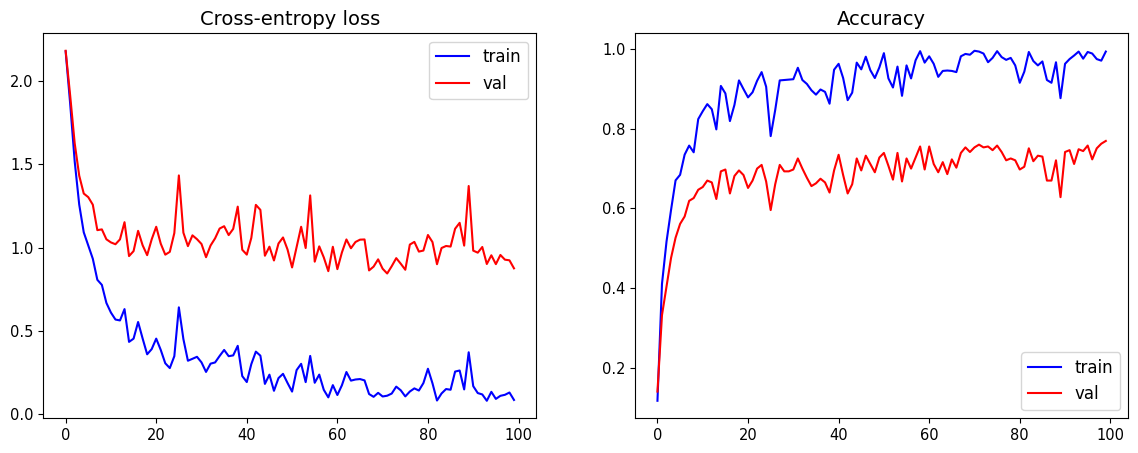

In [93]:
plt.figure(figsize=(14,5))
plt.subplot(1, 2, 1), plt.plot(loss_train, 'b'), plt.plot(loss_val, 'r'), plt.legend(['train', 'val']), plt.title('Cross-entropy loss')
plt.subplot(1, 2, 2), plt.plot(acc_train, 'b'), plt.plot(acc_val, 'r'), plt.legend(['train', 'val']), plt.title('Accuracy')
plt.show()

### <font color='teal'> 5.3. Early stopping </font>
This technique monitors the validation performance and halts training when the improvement stops, preventing overfitting due to excessive training.
It's a bit controversial as we are stopping the model mid training so we are not converging to the optimum solution.

**Key parameters**:
- **patience**: Number of epochs without improvement to wait before stopping.
- **min_delta**: Minimum improvement to consider as improvement.

**Steps to carry out early stopping**:
We will use the following early stopping technique:
1. If the **validation loss does not decrease** for a certain number of epochs, we will stop training.
2. We will **save** the model with the **best validation loss**.
3. We will use the model with the best validation loss to **make predictions** on the test set.

In [94]:
input_dim = train_loader.dataset.tensors[0].shape[1]
hidden_dim = (200, 50, 20)
output_dim = train_loader.dataset.tensors[1].shape[1] if dataset == 'digits' else 1

# Instantiate model class and assign to object
model = FeedforwardNeuralNetModel(input_dim, output_dim, hidden_dim)

# Push model to CUDA device if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

# Loss function
loss_func = nn.BCEWithLogitsLoss() if dataset == 'DogsCats' else nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [96]:
num_epochs = 100
best_accuracy = 0
loss_train = np.zeros(num_epochs)
loss_val = np.zeros(num_epochs)
acc_train = np.zeros(num_epochs)
acc_val = np.zeros(num_epochs)

# Early stopping parameters
early_stop = False 
min_val_loss = float('inf')
patience = 10
min_delta = 0.01
epochs_no_improve = 0

# Check if the best model exists
reg_technique = 'early_stop'
pretrained = False
hidden_dim_str = '_'.join(map(str, hidden_dim))
model_path = f'models/best_model_{dataset}_{reg_technique}_N{int(X_train_torch.shape[0])}_hidden{hidden_dim_str}.pth'
if os.path.exists(model_path) and pretrained:
    print("Loading best model and training history...")
    checkpoint = torch.load(model_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    loss_train = checkpoint['loss_train']
    loss_val = checkpoint['loss_val']
    acc_train = checkpoint['acc_train']
    acc_val = checkpoint['acc_val']
    best_accuracy = checkpoint['best_accuracy']
else:
    print("Best model not found. Running optimization...")

    for epoch in range(num_epochs):

        for xb, yb in train_loader:
            # Ensure the input tensors are of type float32
            xb = xb.float().to(device)
            yb = yb.reshape(-1, 1).float().to(device) if dataset == 'DogsCats' else yb.argmax(axis=-1).to(device)

            #Compute network output and cross-entropy loss for current minibatch
            pred = model(xb)
            loss = loss_func(pred, yb)

            #Compute gradients and optimize parameters
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
                
        #At the end of each epoch, evaluate overall network performance
        with torch.no_grad():
            #Computing network performance after iteration
            pred = model(X_train_torch.float().to(device))
            loss_train[epoch] = loss_func(pred, y_train_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred, y_train_torch.argmax(axis=-1).to(device)).item()
            acc_train[epoch] = accuracy(pred, y_train_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred, y_train_torch.to(device)).item()
            pred_val = model(X_val_torch.float().to(device))
            loss_val[epoch] = loss_func(pred_val, y_val_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred_val, y_val_torch.argmax(axis=-1).to(device)).item()
            acc_val[epoch] = accuracy(pred_val, y_val_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred_val, y_val_torch.to(device)).item()
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss_train[epoch]:.4f}, Accuracy: {acc_train[epoch]:.4f}, Val Loss: {loss_val[epoch]:.4f}, Val Accuracy: {acc_val[epoch]:.4f}')
        
        ### Early Stopping Check ###
        if loss_val[epoch] < min_val_loss - min_delta:
            min_val_loss = loss_val[epoch]
            epochs_no_improve = 0
            torch.save(model.state_dict(), model_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print('Early stopping!')
                loss_val = loss_val[:epoch+1]
                acc_val = acc_val[:epoch+1]
                loss_train = loss_train[:epoch+1]
                acc_train = acc_train[:epoch+1]
                early_stop = True
                break

        # Save model when accuracy beats best accuracy
        if acc_val[epoch] > best_accuracy:
            best_accuracy = acc_val[epoch]
            # Save the model state and training history
            torch.save({
                'model_state_dict': model.state_dict(),
                'loss_train': loss_train,
                'loss_val': loss_val,
                'acc_train': acc_train,
                'acc_val': acc_val,
                'best_accuracy': best_accuracy
            }, model_path)
# Get test performance
with torch.no_grad():
    pred_test = model(X_test_torch.float().to(device))
    loss_test = loss_func(pred_test, y_test_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred_test, y_test_torch.argmax(axis=-1).to(device)).item()
    acc_test = accuracy(pred_test, y_test_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred_test, y_test_torch.to(device)).item()
print(f'Test Loss: {loss_test:.4f}, Test Accuracy: {acc_test:.4f}')

Best model not found. Running optimization...
Epoch [1/100], Loss: 2.0715, Accuracy: 0.3495, Val Loss: 2.1069, Val Accuracy: 0.3349
Epoch [2/100], Loss: 1.6230, Accuracy: 0.4713, Val Loss: 1.7150, Val Accuracy: 0.4480
Epoch [3/100], Loss: 1.2118, Accuracy: 0.6178, Val Loss: 1.3736, Val Accuracy: 0.5173
Epoch [4/100], Loss: 0.9205, Accuracy: 0.7356, Val Loss: 1.1580, Val Accuracy: 0.6005
Epoch [5/100], Loss: 0.7433, Accuracy: 0.7901, Val Loss: 1.0664, Val Accuracy: 0.6420
Epoch [6/100], Loss: 0.6416, Accuracy: 0.8248, Val Loss: 1.0490, Val Accuracy: 0.6582
Epoch [7/100], Loss: 0.5554, Accuracy: 0.8307, Val Loss: 1.0494, Val Accuracy: 0.6559
Epoch [8/100], Loss: 0.4630, Accuracy: 0.8683, Val Loss: 1.0113, Val Accuracy: 0.6605
Epoch [9/100], Loss: 0.4126, Accuracy: 0.8911, Val Loss: 0.9938, Val Accuracy: 0.6790
Epoch [10/100], Loss: 0.3663, Accuracy: 0.9030, Val Loss: 1.0019, Val Accuracy: 0.6767
Epoch [11/100], Loss: 0.3176, Accuracy: 0.9168, Val Loss: 1.0369, Val Accuracy: 0.6836
Epoch 

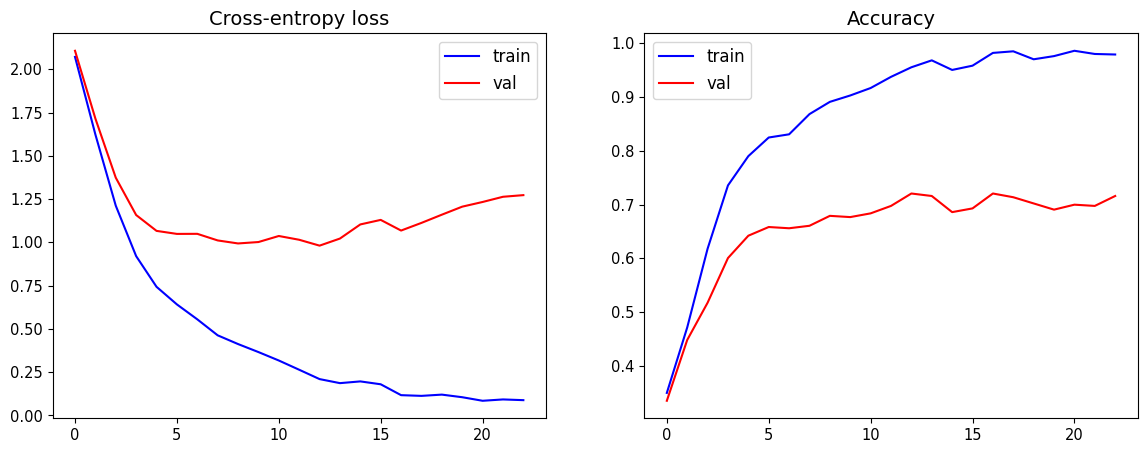

In [97]:
plt.figure(figsize=(14,5))
plt.subplot(1, 2, 1), plt.plot(loss_train, 'b'), plt.plot(loss_val, 'r'), plt.legend(['train', 'val']), plt.title('Cross-entropy loss')
plt.subplot(1, 2, 2), plt.plot(acc_train, 'b'), plt.plot(acc_val, 'r'), plt.legend(['train', 'val']), plt.title('Accuracy')
plt.show()

### <font color='teal'> 5.4. Dropout </font>

Dropout is a regularization technique designed to prevent overfitting in neural networks. It works by randomly deactivating a subset of neurons during each forward pass in training. This forces the network to distribute its learning across a wider set of features, rather than relying on a few specific neurons.

**Key parameters:**
- **Dropout Rate (`p`)**: Defines the proportion of neurons to deactivate (e.g., 20%, 50%).
- **Training vs. Inference**:
  - During **training**, neurons are randomly dropped.
  - During **inference**, dropout is disabled, and weights are scaled (multiplied by 1-`p`) to account for the inherent scaling during training's dropout.

**Steps to carry out dropout**:
1. A dropout mask is applied to the activations of a layer, randomly setting a fraction of them to zero.
2. The unaffected activations remain unchanged, allowing the model to continue training on the remaining subset.

This process ensures the model does not rely too heavily on any single neuron, promoting robust and generalized learning.


In [98]:
class FeedforwardNeuralNetModel(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim= (200, 50, 20), initialize_weights=False, p=0.):
        super(FeedforwardNeuralNetModel, self).__init__()

        sizes = [input_dim] + list(map(int, hidden_dim)) + [output_dim]
        layers = []
        for i in range(len(sizes) - 2):
            layers.append(nn.Linear(sizes[i], sizes[i + 1]))
            if initialize_weights:
                # Initialize weights with Xavier initialization
                torch.nn.init.kaiming_uniform_(layers[-1].weight)
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=p))
        layers.append(nn.Linear(sizes[-2], sizes[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, x):        
        out = self.net(x)    
        return out

In [99]:
input_dim = train_loader.dataset.tensors[0].shape[1]
hidden_dim = (200, 50, 20)
output_dim = train_loader.dataset.tensors[1].shape[1] if dataset == 'digits' else 1

p = 0.5
# Instantiate model class and assign to object
model = FeedforwardNeuralNetModel(input_dim, output_dim, hidden_dim, p = p)

# Push model to CUDA device if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

# Loss function
loss_func = nn.BCEWithLogitsLoss() if dataset == 'DogsCats' else nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [100]:
num_epochs = 100
best_accuracy = 0
loss_train = np.zeros(num_epochs)
loss_val = np.zeros(num_epochs)
acc_train = np.zeros(num_epochs)
acc_val = np.zeros(num_epochs)

# Check if the best model exists
reg_technique = 'dropout'
pretrained = False
hidden_dim_str = '_'.join(map(str, hidden_dim))
model_path = f'models/best_model_{dataset}_{reg_technique}_{p}_N{int(X_train_torch.shape[0])}_hidden{hidden_dim_str}.pth'
if os.path.exists(model_path) and pretrained:
    print("Loading best model and training history...")
    checkpoint = torch.load(model_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    loss_train = checkpoint['loss_train']
    loss_val = checkpoint['loss_val']
    acc_train = checkpoint['acc_train']
    acc_val = checkpoint['acc_val']
    best_accuracy = checkpoint['best_accuracy']
else:
    print("Best model not found. Running optimization...")

    for epoch in range(num_epochs):

        for xb, yb in train_loader:
            # Ensure the input tensors are of type float32
            xb = xb.float().to(device)
            yb = yb.reshape(-1, 1).float().to(device) if dataset == 'DogsCats' else yb.argmax(axis=-1).to(device)

            #Compute network output and cross-entropy loss for current minibatch
            pred = model(xb)
            loss = loss_func(pred, yb)

            #Compute gradients and optimize parameters
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
                
        #At the end of each epoch, evaluate overall network performance
        with torch.no_grad():
            #Computing network performance after iteration
            pred = model(X_train_torch.float().to(device))
            loss_train[epoch] = loss_func(pred, y_train_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred, y_train_torch.argmax(axis=-1).to(device)).item()
            acc_train[epoch] = accuracy(pred, y_train_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred, y_train_torch.to(device)).item()
            pred_val = model(X_val_torch.float().to(device))
            loss_val[epoch] = loss_func(pred_val, y_val_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred_val, y_val_torch.argmax(axis=-1).to(device)).item()
            acc_val[epoch] = accuracy(pred_val, y_val_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred_val, y_val_torch.to(device)).item()
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss_train[epoch]:.4f}, Accuracy: {acc_train[epoch]:.4f}, Val Loss: {loss_val[epoch]:.4f}, Val Accuracy: {acc_val[epoch]:.4f}')
        
        # Save model when accuracy beats best accuracy
        if acc_val[epoch] > best_accuracy:
            best_accuracy = acc_val[epoch]
            # Save the model state and training history
            torch.save({
                'model_state_dict': model.state_dict(),
                'loss_train': loss_train,
                'loss_val': loss_val,
                'acc_train': acc_train,
                'acc_val': acc_val,
                'best_accuracy': best_accuracy
            }, model_path)
# Get test performance
with torch.no_grad():
    pred_test = model(X_test_torch.float().to(device))
    loss_test = loss_func(pred_test, y_test_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred_test, y_test_torch.argmax(axis=-1).to(device)).item()
    acc_test = accuracy(pred_test, y_test_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred_test, y_test_torch.to(device)).item()
print(f'Test Loss: {loss_test:.4f}, Test Accuracy: {acc_test:.4f}')

Best model not found. Running optimization...
Epoch [1/100], Loss: 2.3141, Accuracy: 0.1178, Val Loss: 2.3082, Val Accuracy: 0.1178
Epoch [2/100], Loss: 2.3033, Accuracy: 0.1089, Val Loss: 2.2881, Val Accuracy: 0.1155
Epoch [3/100], Loss: 2.2975, Accuracy: 0.1297, Val Loss: 2.2746, Val Accuracy: 0.1363
Epoch [4/100], Loss: 2.2474, Accuracy: 0.1535, Val Loss: 2.2480, Val Accuracy: 0.1686
Epoch [5/100], Loss: 2.2071, Accuracy: 0.1713, Val Loss: 2.2339, Val Accuracy: 0.1363
Epoch [6/100], Loss: 2.1476, Accuracy: 0.2000, Val Loss: 2.1831, Val Accuracy: 0.1963
Epoch [7/100], Loss: 2.1197, Accuracy: 0.2129, Val Loss: 2.1615, Val Accuracy: 0.2009
Epoch [8/100], Loss: 2.0569, Accuracy: 0.2446, Val Loss: 2.0960, Val Accuracy: 0.1963
Epoch [9/100], Loss: 2.0019, Accuracy: 0.2554, Val Loss: 2.0358, Val Accuracy: 0.2656
Epoch [10/100], Loss: 1.9458, Accuracy: 0.2861, Val Loss: 2.0859, Val Accuracy: 0.2032
Epoch [11/100], Loss: 1.9105, Accuracy: 0.3139, Val Loss: 1.9887, Val Accuracy: 0.2725
Epoch 

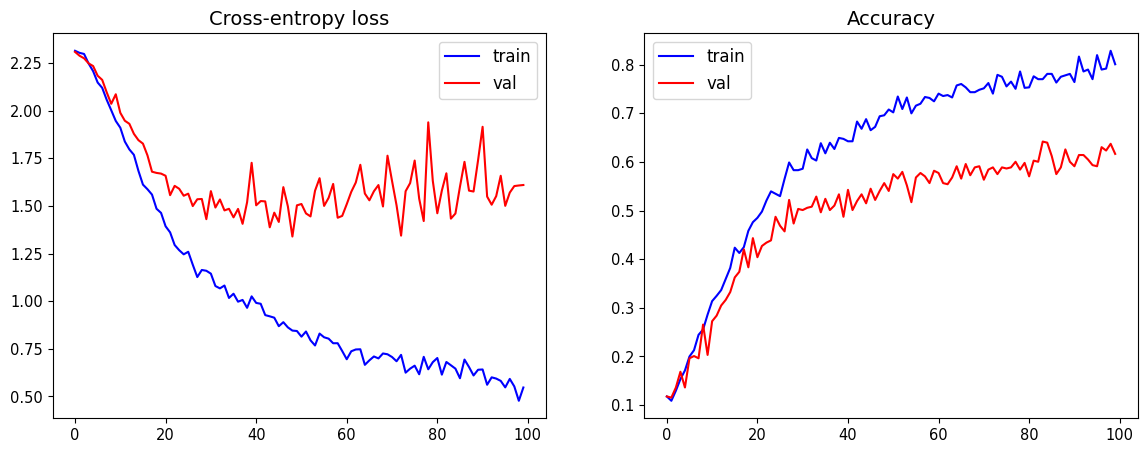

In [101]:
plt.figure(figsize=(14,5))
plt.subplot(1, 2, 1), plt.plot(loss_train, 'b'), plt.plot(loss_val, 'r'), plt.legend(['train', 'val']), plt.title('Cross-entropy loss')
plt.subplot(1, 2, 2), plt.plot(acc_train, 'b'), plt.plot(acc_val, 'r'), plt.legend(['train', 'val']), plt.title('Accuracy')
plt.show()

### <font color='teal'> 6. Indirect regularisation </font>

Here, we will present techniques that are not explicitly designed as regularization techniques but have a similar impact by improving generalization as a side effect.

### <font color='teal'> 6.1. Batch Normalisation </font>
Batch Normalization is a technique to stabilize and accelerate the training of deep neural networks by normalizing the inputs to each layer. It ensures that the inputs to a layer have a consistent distribution throughout training, which can help mitigate issues caused by internal covariate shift.

**Benefits of Batch Normalization**
1. **Faster Convergence**: Normalized inputs allow the network to learn faster, often reducing the number of epochs required.
2. **Higher Learning Rates**: Helps the model tolerate larger learning rates without divergence.
3. **Regularization**: Introduces noise through mini-batch statistics, reducing the dependency on dropout or other regularization techniques.
4. **Reduced Internal Covariate Shift**: Stabilizes the distribution of activations, making deeper networks easier to train.

In [102]:
class FeedforwardNeuralNetModel(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim= (200, 50, 20), initialize_weights=False, p=0., use_batchnorm=False):
        super(FeedforwardNeuralNetModel, self).__init__()

        sizes = [input_dim] + list(map(int, hidden_dim)) + [output_dim]
        layers = []
        for i in range(len(sizes) - 2):
            layers.append(nn.Linear(sizes[i], sizes[i + 1]))
            if initialize_weights:
                torch.nn.init.kaiming_uniform_(layers[-1].weight)
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(sizes[i + 1]))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=p))
        layers.append(nn.Linear(sizes[-2], sizes[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, x):        
        out = self.net(x)    
        return out

In [103]:
input_dim = train_loader.dataset.tensors[0].shape[1]
hidden_dim = (200, 50, 20)
output_dim = train_loader.dataset.tensors[1].shape[1] if dataset == 'digits' else 1

# Instantiate model class and assign to object
model = FeedforwardNeuralNetModel(input_dim, output_dim, hidden_dim, use_batchnorm=True)

# Push model to CUDA device if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

# Loss function
loss_func = nn.BCEWithLogitsLoss() if dataset == 'DogsCats' else nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [104]:
num_epochs = 100
best_accuracy = 0
loss_train = np.zeros(num_epochs)
loss_val = np.zeros(num_epochs)
acc_train = np.zeros(num_epochs)
acc_val = np.zeros(num_epochs)

# Check if the best model exists
reg_technique = 'batchnorm'
pretrained = False
hidden_dim_str = '_'.join(map(str, hidden_dim))
model_path = f'models/best_model_{dataset}_{reg_technique}_N{int(X_train_torch.shape[0])}_hidden{hidden_dim_str}.pth'
if os.path.exists(model_path) and pretrained:
    print("Loading best model and training history...")
    checkpoint = torch.load(model_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    loss_train = checkpoint['loss_train']
    loss_val = checkpoint['loss_val']
    acc_train = checkpoint['acc_train']
    acc_val = checkpoint['acc_val']
    best_accuracy = checkpoint['best_accuracy']
else:
    print("Best model not found. Running optimization...")

    for epoch in range(num_epochs):

        for xb, yb in train_loader:
            # Ensure the input tensors are of type float32
            xb = xb.float().to(device)
            yb = yb.reshape(-1, 1).float().to(device) if dataset == 'DogsCats' else yb.argmax(axis=-1).to(device)

            #Compute network output and cross-entropy loss for current minibatch
            pred = model(xb)
            loss = loss_func(pred, yb)

            #Compute gradients and optimize parameters
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
                
        #At the end of each epoch, evaluate overall network performance
        with torch.no_grad():
            #Computing network performance after iteration
            pred = model(X_train_torch.float().to(device))
            loss_train[epoch] = loss_func(pred, y_train_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred, y_train_torch.argmax(axis=-1).to(device)).item()
            acc_train[epoch] = accuracy(pred, y_train_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred, y_train_torch.to(device)).item()
            pred_val = model(X_val_torch.float().to(device))
            loss_val[epoch] = loss_func(pred_val, y_val_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred_val, y_val_torch.argmax(axis=-1).to(device)).item()
            acc_val[epoch] = accuracy(pred_val, y_val_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred_val, y_val_torch.to(device)).item()
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss_train[epoch]:.4f}, Accuracy: {acc_train[epoch]:.4f}, Val Loss: {loss_val[epoch]:.4f}, Val Accuracy: {acc_val[epoch]:.4f}')
        
        # Save model when accuracy beats best accuracy
        if acc_val[epoch] > best_accuracy:
            best_accuracy = acc_val[epoch]
            # Save the model state and training history
            torch.save({
                'model_state_dict': model.state_dict(),
                'loss_train': loss_train,
                'loss_val': loss_val,
                'acc_train': acc_train,
                'acc_val': acc_val,
                'best_accuracy': best_accuracy
            }, model_path)
# Get test performance
with torch.no_grad():
    pred_test = model(X_test_torch.float().to(device))
    loss_test = loss_func(pred_test, y_test_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred_test, y_test_torch.argmax(axis=-1).to(device)).item()
    acc_test = accuracy(pred_test, y_test_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred_test, y_test_torch.to(device)).item()
print(f'Test Loss: {loss_test:.4f}, Test Accuracy: {acc_test:.4f}')

Best model not found. Running optimization...
Epoch [1/100], Loss: 1.7079, Accuracy: 0.5693, Val Loss: 1.8493, Val Accuracy: 0.4388
Epoch [2/100], Loss: 1.4463, Accuracy: 0.7356, Val Loss: 1.6421, Val Accuracy: 0.5543
Epoch [3/100], Loss: 1.2492, Accuracy: 0.8228, Val Loss: 1.4992, Val Accuracy: 0.6351
Epoch [4/100], Loss: 1.0709, Accuracy: 0.8782, Val Loss: 1.3914, Val Accuracy: 0.6697
Epoch [5/100], Loss: 0.9084, Accuracy: 0.9287, Val Loss: 1.2944, Val Accuracy: 0.6790
Epoch [6/100], Loss: 0.7681, Accuracy: 0.9564, Val Loss: 1.2246, Val Accuracy: 0.7021
Epoch [7/100], Loss: 0.6563, Accuracy: 0.9673, Val Loss: 1.1574, Val Accuracy: 0.7159
Epoch [8/100], Loss: 0.5392, Accuracy: 0.9752, Val Loss: 1.0662, Val Accuracy: 0.7390
Epoch [9/100], Loss: 0.4608, Accuracy: 0.9851, Val Loss: 1.0431, Val Accuracy: 0.7460
Epoch [10/100], Loss: 0.3862, Accuracy: 0.9842, Val Loss: 1.0058, Val Accuracy: 0.7390
Epoch [11/100], Loss: 0.3505, Accuracy: 0.9851, Val Loss: 1.0096, Val Accuracy: 0.7252
Epoch 

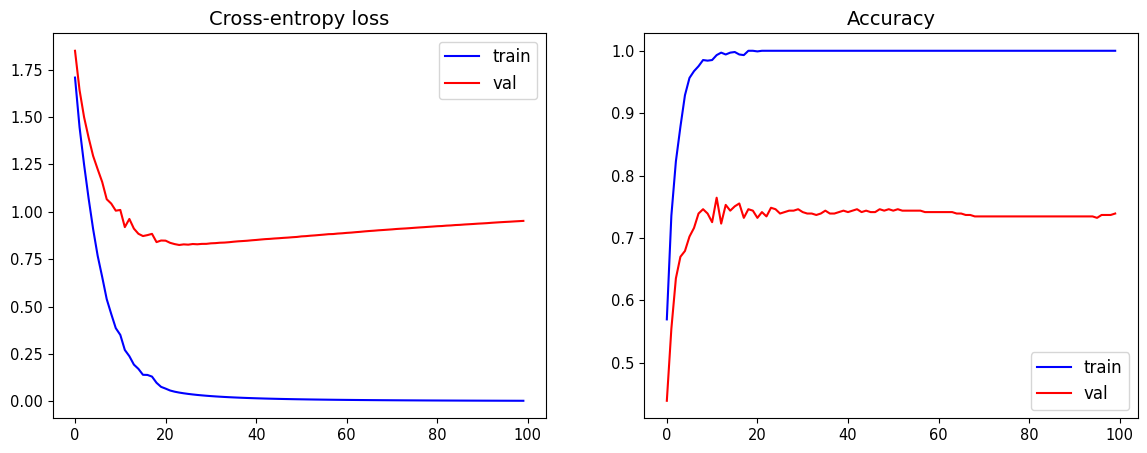

In [106]:
plt.figure(figsize=(14,5))
plt.subplot(1, 2, 1), plt.plot(loss_train, 'b'), plt.plot(loss_val, 'r'), plt.legend(['train', 'val']), plt.title('Cross-entropy loss')
plt.subplot(1, 2, 2), plt.plot(acc_train, 'b'), plt.plot(acc_val, 'r'), plt.legend(['train', 'val']), plt.title('Accuracy')
plt.show()

### <font color='teal'> 6.2. Data augmentation </font>
Data augmentation is a technique used to artificially increase the size and diversity of a training dataset by applying transformations or perturbations to the existing data. It is commonly used in computer vision and natural language processing, to improve model generalization and reduce overfitting.

**Benefits of data augmentation**
1. **Improves Generalization**: Models trained on augmented data are exposed to diverse variations of the input, making them more robust to unseen data.
2. **Mitigates Overfitting**: By artificially enlarging the dataset, the model learns from more examples, reducing its tendency to memorize the training set.
3. **Increases Data Size**: Augmented datasets effectively provide more samples without collecting new data, which is beneficial for tasks with limited training data.

**Common Data Augmentation Techniques**
- **For Images:**
1. **Geometric Transformations**: Rotation, flipping, cropping, scaling, and translation.
2. **Color Transformations**: Adjust brightness, contrast, saturation, and hue.
3. **Noise Injection**: Add Gaussian noise or salt-and-pepper noise to simulate real-world imperfections.
4. **Random Erasing**: Randomly erase a portion of the image to mimic occlusions.
- **For Text:**
1. **Synonym Replacement**: Replace words with their synonyms to introduce variations.
2. **Back Translation**: Translate text to another language and back to introduce subtle paraphrasing.
3. **Word Deletion or Shuffling**: Randomly remove or shuffle words in a sentence.
- **For Time-Series or Audio:**
1. **Time Stretching/Compression**: Speed up or slow down the audio signal.
2. **Pitch Shifting**: Shift the frequency of the audio.
3. **Adding Noise**: Overlay random noise to the signal.

Let's start by generating new samples with rotations and brightness and contrast.

Original dataset size: 1010, Augmented dataset size: 6060


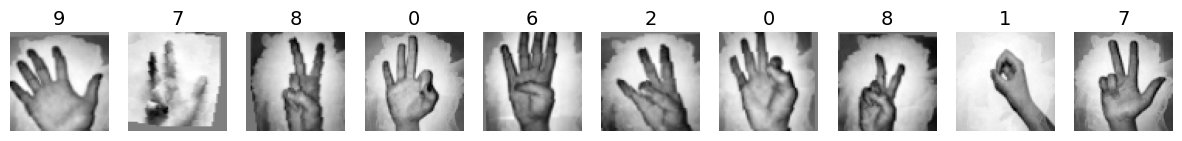

In [120]:
import torch
from torch.utils.data import DataLoader, TensorDataset, ConcatDataset
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Define the data augmentation transformations
transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
])


# Create a function to generate augmented samples
def create_augmented_samples(X, y, transform, num_augmentations=1):
    augmented_samples = []
    augmented_labels = []
    for i in range(len(X)):
        original = X[i]
        label = y[i]

        # Add channel dimension: [H,W] -> [1,H,W]
        original = original.unsqueeze(0)

        for _ in range(num_augmentations):
            augmented_sample = transform(original)
            augmented_samples.append(augmented_sample)
            augmented_labels.append(label)

    return torch.stack(augmented_samples), torch.stack(augmented_labels)


# Original dataset (reshaped for transformation compatibility)
X_train_reshaped = X_train_torch.reshape(-1, 1, img_size, img_size)
y_train = y_train_torch

# Generate augmented samples (e.g., 2 augmentations per original sample)
num_augmentations = 5
aug_X, aug_y = create_augmented_samples(X_train_reshaped, y_train, transform, num_augmentations=num_augmentations)

# Combine original and augmented datasets
augmented_X = torch.cat([X_train_reshaped.unsqueeze(1), aug_X])
augmented_y = torch.cat([y_train, aug_y])  # Combine the one-hot encoded labels
print(f'Original dataset size: {X_train_reshaped.shape[0]}, Augmented dataset size: {augmented_X.shape[0]}')
# Create a new DataLoader for the combined dataset
augmented_dataset = TensorDataset(augmented_X, augmented_y)
train_loader_augmented = DataLoader(augmented_dataset, batch_size=batch_size, shuffle=True)

# Verify the augmented dataset by visualizing some samples
images, labels = next(iter(train_loader_augmented))

def show_images(images, labels, n=10):
    plt.figure(figsize=(15, 5))
    for i in range(n):
        ax = plt.subplot(1, n, i + 1)
        plt.imshow(images[i].squeeze().numpy(), cmap="gray")
        plt.title(labels[i].argmax().item())
        plt.axis("off")
    plt.show()

# Get a batch of augmented images
images, labels = next(iter(train_loader_augmented))
show_images(images, labels)


The visualisation shows that there are some slight changes in the values of our images. Note that converting to and from PIL may introduce small interpolation effects.

In [121]:
input_dim = train_loader.dataset.tensors[0].shape[1]
hidden_dim = (200, 50, 20)
output_dim = train_loader.dataset.tensors[1].shape[1] if dataset == 'digits' else 1

# Instantiate model class and assign to object
model = FeedforwardNeuralNetModel(input_dim, output_dim, hidden_dim)

# Push model to CUDA device if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

# Loss function
loss_func = nn.BCEWithLogitsLoss() if dataset == 'DogsCats' else nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [122]:
num_epochs = 100
best_accuracy = 0
loss_train = np.zeros(num_epochs)
loss_val = np.zeros(num_epochs)
acc_train = np.zeros(num_epochs)
acc_val = np.zeros(num_epochs)

# Check if the best model exists
reg_technique = 'batchnorm'
pretrained = False
hidden_dim_str = '_'.join(map(str, hidden_dim))
model_path = f'models/best_model_{dataset}_{reg_technique}_N{int(X_train_torch.shape[0])}_hidden{hidden_dim_str}.pth'
if os.path.exists(model_path) and pretrained:
    print("Loading best model and training history...")
    checkpoint = torch.load(model_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    loss_train = checkpoint['loss_train']
    loss_val = checkpoint['loss_val']
    acc_train = checkpoint['acc_train']
    acc_val = checkpoint['acc_val']
    best_accuracy = checkpoint['best_accuracy']
else:
    print("Best model not found. Running optimization...")

    for epoch in range(num_epochs):

        for xb, yb in train_loader_augmented:
            # Ensure the input tensors are of type float32
            xb = xb.float().reshape(-1, img_size * img_size).to(device)
            yb = yb.reshape(-1, 1).float().to(device) if dataset == 'DogsCats' else yb.argmax(axis=-1).to(device)

            #Compute network output and cross-entropy loss for current minibatch
            pred = model(xb)
            loss = loss_func(pred, yb)

            #Compute gradients and optimize parameters
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
                
        #At the end of each epoch, evaluate overall network performance
        with torch.no_grad():
            #Computing network performance after iteration
            pred = model(X_train_torch.float().to(device))
            loss_train[epoch] = loss_func(pred, y_train_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred, y_train_torch.argmax(axis=-1).to(device)).item()
            acc_train[epoch] = accuracy(pred, y_train_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred, y_train_torch.to(device)).item()
            pred_val = model(X_val_torch.float().to(device))
            loss_val[epoch] = loss_func(pred_val, y_val_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred_val, y_val_torch.argmax(axis=-1).to(device)).item()
            acc_val[epoch] = accuracy(pred_val, y_val_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred_val, y_val_torch.to(device)).item()
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss_train[epoch]:.4f}, Accuracy: {acc_train[epoch]:.4f}, Val Loss: {loss_val[epoch]:.4f}, Val Accuracy: {acc_val[epoch]:.4f}')
        
        # Save model when accuracy beats best accuracy
        if acc_val[epoch] > best_accuracy:
            best_accuracy = acc_val[epoch]
            # Save the model state and training history
            torch.save({
                'model_state_dict': model.state_dict(),
                'loss_train': loss_train,
                'loss_val': loss_val,
                'acc_train': acc_train,
                'acc_val': acc_val,
                'best_accuracy': best_accuracy
            }, model_path)
# Get test performance
with torch.no_grad():
    pred_test = model(X_test_torch.float().to(device))
    loss_test = loss_func(pred_test, y_test_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else loss_func(pred_test, y_test_torch.argmax(axis=-1).to(device)).item()
    acc_test = accuracy(pred_test, y_test_torch.reshape(-1, 1).float().to(device)).item() if dataset == 'DogsCats' else accuracy(pred_test, y_test_torch.to(device)).item()
print(f'Test Loss: {loss_test:.4f}, Test Accuracy: {acc_test:.4f}')

Best model not found. Running optimization...
Epoch [1/100], Loss: 1.1744, Accuracy: 0.5792, Val Loss: 1.3152, Val Accuracy: 0.5589
Epoch [2/100], Loss: 0.7600, Accuracy: 0.7802, Val Loss: 0.9664, Val Accuracy: 0.6928
Epoch [3/100], Loss: 0.5372, Accuracy: 0.8297, Val Loss: 0.8499, Val Accuracy: 0.7113
Epoch [4/100], Loss: 0.4382, Accuracy: 0.8723, Val Loss: 0.8393, Val Accuracy: 0.7344
Epoch [5/100], Loss: 0.2904, Accuracy: 0.9109, Val Loss: 0.6631, Val Accuracy: 0.7921
Epoch [6/100], Loss: 0.2107, Accuracy: 0.9515, Val Loss: 0.6193, Val Accuracy: 0.8106
Epoch [7/100], Loss: 0.1756, Accuracy: 0.9525, Val Loss: 0.6401, Val Accuracy: 0.7875
Epoch [8/100], Loss: 0.1183, Accuracy: 0.9733, Val Loss: 0.5941, Val Accuracy: 0.8245
Epoch [9/100], Loss: 0.1057, Accuracy: 0.9723, Val Loss: 0.6551, Val Accuracy: 0.8014
Epoch [10/100], Loss: 0.0772, Accuracy: 0.9772, Val Loss: 0.6358, Val Accuracy: 0.8291
Epoch [11/100], Loss: 0.0491, Accuracy: 0.9871, Val Loss: 0.6283, Val Accuracy: 0.8291
Epoch 

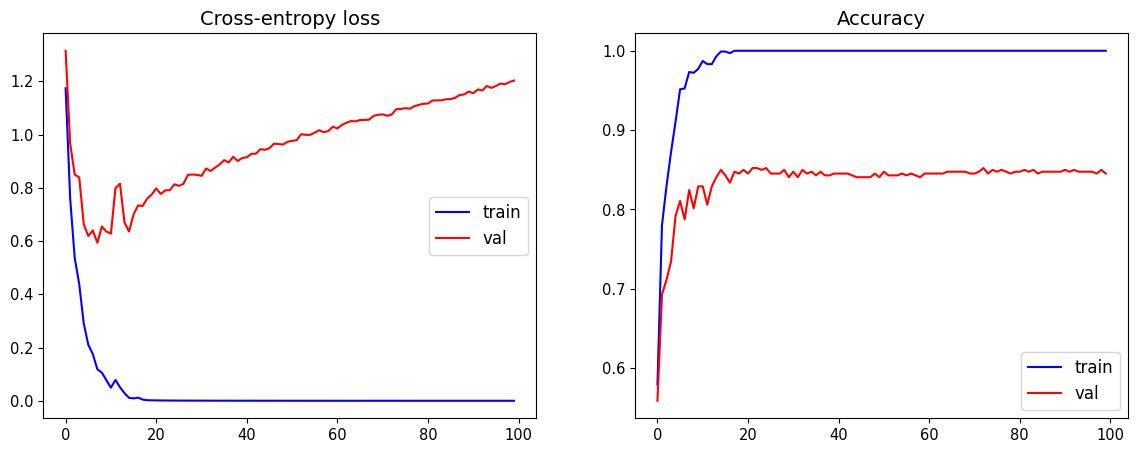

In [123]:
plt.figure(figsize=(14,5))
plt.subplot(1, 2, 1), plt.plot(loss_train, 'b'), plt.plot(loss_val, 'r'), plt.legend(['train', 'val']), plt.title('Cross-entropy loss')
plt.subplot(1, 2, 2), plt.plot(acc_train, 'b'), plt.plot(acc_val, 'r'), plt.legend(['train', 'val']), plt.title('Accuracy')
plt.show()

Now that you have learned how to implement regularization techniques in PyTorch, you can experiment with different regularization techniques and hyperparameters to improve the performance of your neural network models. You can also try different datasets and network architectures to see how regularization techniques affect the training and generalization of deep learning models.